# CSE475 — Task 2: Baseline Models
## Track 1 — GNN on NinaPro DB1 (Classification)

Dataset: `/kaggle/input/datasets/hoixding/nianpro-db1` (official raw NinaPro DB1 `.mat`
files — 81 files = 27 subjects x 3 exercises).



## 1. Imports & Configuration

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # suppresses TensorFlow's INFO/WARNING logs

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

import os
import glob
import warnings
import time
import numpy as np
import pandas as pd
from scipy.io import loadmat
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from imblearn.over_sampling import SMOTE

# Classical ML models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# XGBoost and LightGBM (optional)
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False

try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except ImportError:
    lgbm_available = False

# Deep learning
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models as keras_models
    tf_available = True
except ImportError:
    tf_available = False

warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")
warnings.filterwarnings("ignore", category=UserWarning, module="xgboost")

DATASET_PATH = "/kaggle/input/datasets/hoixding/nianpro-db1"   # adjust if needed
print("Libraries loaded.")
print(f"XGBoost available: {xgb_available}, LightGBM: {lgbm_available}, TF: {tf_available}")

Libraries loaded.
XGBoost available: True, LightGBM: True, TF: True


## 2. Load All MAT Files and Build Raw DataFrame

Loads all 81 official `.mat` files (27 subjects x 3 exercises) into one combined table
with EMG, glove, gesture label (`restimulus`), repetition, subject, and exercise
columns.

In [2]:
mat_files = sorted(glob.glob(os.path.join(DATASET_PATH, "s*", "*.mat")))
print(f"Total MAT files: {len(mat_files)}")

all_data = []
for file in mat_files:
    mat = loadmat(file)
    emg = pd.DataFrame(mat["emg"], columns=[f"emg_{i}" for i in range(10)])
    glove = pd.DataFrame(mat["glove"], columns=[f"glove_{i}" for i in range(22)])
    df = pd.concat([emg, glove], axis=1)
    df["restimulus"] = mat["restimulus"].flatten()
    df["repetition"] = mat["repetition"].flatten()
    subject = int(os.path.basename(os.path.dirname(file)).replace("s",""))
    df["subject"] = subject
    exercise = int(file.split("_E")[-1].split(".")[0])
    df["exercise"] = exercise
    all_data.append(df)

dataset = pd.concat(all_data, ignore_index=True)
print(f"Dataset shape: {dataset.shape}")

# Keep only needed columns
keep_cols = [f"emg_{i}" for i in range(10)] + [f"glove_{i}" for i in range(22)] + \
            ["restimulus", "repetition", "subject", "exercise"]
dataset = dataset[keep_cols]

Total MAT files: 81
Dataset shape: (12553611, 36)


## 3. Preprocessing — Feature Extraction for Classical ML Models (No Leakage)

Windowed feature extraction: RMS, MAV, WL, VAR per channel per window, grouped by
(subject, exercise, repetition, gesture) so no window spans multiple gestures. Rest
(gesture 0) is excluded — see the note at the top of this notebook.

In [3]:
WINDOW_SIZE = 200
STEP_SIZE   = 100
ALL_CHANNELS = [f"emg_{i}" for i in range(10)] + [f"glove_{i}" for i in range(22)]

def rms(x):    return np.sqrt(np.mean(x**2))
def mav(x):    return np.mean(np.abs(x))
def wl(x):     return np.sum(np.abs(np.diff(x)))
def var(x):    return np.var(x)

print("\nExtracting features for ML models...")
features = []
labels = []
subjects = []
exercises = []

for (subject, exercise, repetition, gesture), group in dataset.groupby(
    ["subject", "exercise", "repetition", "restimulus"]
):
    if gesture == 0:
        continue
    group = group.reset_index(drop=True)
    if len(group) < WINDOW_SIZE:
        continue
    for start in range(0, len(group)-WINDOW_SIZE+1, STEP_SIZE):
        window = group.iloc[start:start+WINDOW_SIZE]
        feat_vec = []
        for ch in ALL_CHANNELS:
            signal = window[ch].values
            feat_vec.extend([rms(signal), mav(signal), wl(signal), var(signal)])
        features.append(feat_vec)
        labels.append(gesture)
        subjects.append(subject)
        exercises.append(exercise)

print(f"Total windows: {len(features)}")

feature_names = []
for ch in ALL_CHANNELS:
    for feat in ["RMS", "MAV", "WL", "VAR"]:
        feature_names.append(f"{ch}_{feat}")

feature_df = pd.DataFrame(features, columns=feature_names)
feature_df["label"] = labels
feature_df["subject"] = subjects
feature_df["exercise"] = exercises


Extracting features for ML models...
Total windows: 30936


## 4. Train / Test Split (Subject-Independent) — No Leakage

Subjects 1–20 for training, 21–27 for testing — a clean subject-independent split per
§6.2, with all preprocessing (imputation, scaling, feature selection, SMOTE) fit on
training data only.

In [4]:
train_df = feature_df[feature_df["subject"].between(1,20)].reset_index(drop=True)
test_df  = feature_df[feature_df["subject"].between(21,27)].reset_index(drop=True)

X_train = train_df.drop(columns=["label", "subject", "exercise"])
y_train = train_df["label"]
X_test  = test_df.drop(columns=["label", "subject", "exercise"])
y_test  = test_df["label"]

# Encode labels (fit on training only)
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_test_enc  = encoder.transform(y_test)

print(f"ML Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# -----------------------------------------------------------------------------
# Preprocessing pipeline on training data only
# 1. Missing values (if any)
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed  = imputer.transform(X_test)

# 2. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled  = scaler.transform(X_test_imputed)

# 3. Feature selection (mutual information, top 100)
selector = SelectKBest(mutual_info_classif, k=100)
X_train_sel = selector.fit_transform(X_train_scaled, y_train_enc)
X_test_sel  = selector.transform(X_test_scaled)

# 4. SMOTE - applied only on training data (no leakage)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_sel, y_train_enc)
print(f"After SMOTE: {X_train_res.shape[0]} samples")

ML Train samples: 22724, Test samples: 8212
After SMOTE: 30360 samples


## 5. Evaluation Metrics (Weighted — as originally defined)

In [5]:
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return acc, prec, rec, f1

## 6. Train and Evaluate Classical ML Models

**Note (small necessary addition):** three lines are added inside this loop —
`trained_models[name] = model`, `model_predictions[name] = y_pred`, and
`model_probabilities[name] = ...` — to preserve the fitted models, predictions, and
class probabilities for the full §6.1 metric set (macro metrics, confusion matrix,
ROC/PR curves) computed in Section 6b below. No model configuration, training data, or
evaluation logic has been changed.

In [6]:
ml_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM (rbf)": SVC(kernel='rbf', C=1, gamma='scale', random_state=42, probability=True),
    "k-NN (k=7)": KNeighborsClassifier(n_neighbors=7, weights='distance'),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42),
}
if xgb_available:
    ml_models["XGBoost"] = XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.1,
                                         subsample=0.8, colsample_bytree=0.8,
                                         eval_metric='mlogloss', random_state=42, n_jobs=-1)
if lgbm_available:
    ml_models["LightGBM"] = LGBMClassifier(n_estimators=200, max_depth=7, learning_rate=0.1,
                                           subsample=0.8, colsample_bytree=0.8,
                                           random_state=42, n_jobs=-1, verbosity=-1)

results = []
trained_models = {}       # ADDED: preserve fitted models
model_predictions = {}    # ADDED: preserve predictions
model_probabilities = {}  # ADDED: preserve class probabilities (for ROC/PR curves)

print("\n" + "="*70)
print("Training and evaluating ML baselines...")
print("="*70)

for name, model in ml_models.items():
    print(f"\n>>> {name}")
    start_time = time.time()
    model.fit(X_train_res, y_train_res)
    train_time = time.time() - start_time
    y_pred = model.predict(X_test_sel)
    acc, prec, rec, f1 = compute_metrics(y_test_enc, y_pred)
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, Time: {train_time:.2f}s")
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "Train Time (s)": train_time
    })

    # --- ADDED: preserve model/predictions/probabilities for full metrics section ---
    trained_models[name] = model
    model_predictions[name] = y_pred
    model_probabilities[name] = model.predict_proba(X_test_sel) if hasattr(model, "predict_proba") else None


Training and evaluating ML baselines...

>>> Logistic Regression
Accuracy: 0.6231, Precision: 0.6663, Recall: 0.6231, F1: 0.6244, Time: 18.30s

>>> SVM (rbf)
Accuracy: 0.7746, Precision: 0.7836, Recall: 0.7746, F1: 0.7750, Time: 100.88s

>>> k-NN (k=7)
Accuracy: 0.6841, Precision: 0.6930, Recall: 0.6841, F1: 0.6853, Time: 0.00s

>>> Decision Tree
Accuracy: 0.4664, Precision: 0.4687, Recall: 0.4664, F1: 0.4607, Time: 9.58s

>>> Random Forest
Accuracy: 0.7482, Precision: 0.7536, Recall: 0.7482, F1: 0.7462, Time: 20.34s

>>> MLP
Accuracy: 0.6874, Precision: 0.7082, Recall: 0.6874, F1: 0.6865, Time: 44.42s

>>> XGBoost
Accuracy: 0.7306, Precision: 0.7473, Recall: 0.7306, F1: 0.7302, Time: 61.06s

>>> LightGBM
Accuracy: 0.7404, Precision: 0.7593, Recall: 0.7404, F1: 0.7423, Time: 34.30s


## 7. Identify the Best Classical Baseline ("Baseline to Beat")

In [7]:
ml_results_df = pd.DataFrame(results)
best_classical = ml_results_df.loc[ml_results_df["Accuracy"].idxmax()]
print("\n" + "="*70)
print("BEST CLASSICAL BASELINE (Baseline to Beat)")
print("="*70)
print(best_classical[["Model", "Accuracy", "Precision", "Recall", "F1", "Train Time (s)"]])


BEST CLASSICAL BASELINE (Baseline to Beat)
Model             SVM (rbf)
Accuracy           0.774598
Precision          0.783605
Recall             0.774598
F1                 0.775034
Train Time (s)    100.88177
Name: 1, dtype: object


## 6b. Full §6.1 Metric Set — Macro Metrics, Confusion Matrix, ROC-AUC & PR-AUC (OvR)

The comparison table above uses weighted averages, which can mask per-class weakness on
imbalanced data (a class with few test samples barely moves a weighted average). This
section adds the macro-averaged metrics, confusion matrix, and ROC/PR curves that §6.1
requires, computed from the preserved models/predictions/probabilities above.

In [8]:
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

all_classes = sorted(np.unique(y_test_enc))
y_test_bin = label_binarize(y_test_enc, classes=all_classes)

macro_results = []
for name in trained_models.keys():
    y_pred = model_predictions[name]
    y_proba = model_probabilities[name]

    macro_prec = precision_score(y_test_enc, y_pred, average='macro', zero_division=0)
    macro_rec = recall_score(y_test_enc, y_pred, average='macro', zero_division=0)
    macro_f1 = f1_score(y_test_enc, y_pred, average='macro', zero_division=0)

    roc_auc, pr_auc = None, None
    if y_proba is not None:
        try:
            roc_auc = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
            pr_auc = average_precision_score(y_test_bin, y_proba, average='macro')
        except Exception:
            pass

    macro_results.append({
        "Model": name, "Macro-Precision": macro_prec, "Macro-Recall": macro_rec,
        "Macro-F1": macro_f1, "ROC-AUC (macro, OvR)": roc_auc, "PR-AUC (macro, OvR)": pr_auc
    })

macro_df = pd.DataFrame(macro_results).sort_values("Macro-F1", ascending=False)
print(macro_df.round(4))

best_macro_name = macro_df.iloc[0]["Model"]
print(f"\nBest model by Macro-F1: {best_macro_name} (may differ from the weighted-accuracy leader above)")

                 Model  Macro-Precision  Macro-Recall  Macro-F1  \
1            SVM (rbf)           0.7906        0.7879    0.7842   
4        Random Forest           0.7572        0.7576    0.7514   
7             LightGBM           0.7668        0.7467    0.7480   
6              XGBoost           0.7601        0.7392    0.7400   
5                  MLP           0.7185        0.7106    0.7031   
2           k-NN (k=7)           0.6876        0.7018    0.6903   
0  Logistic Regression           0.6869        0.6606    0.6560   
3        Decision Tree           0.4802        0.4755    0.4715   

   ROC-AUC (macro, OvR)  PR-AUC (macro, OvR)  
1                0.9814               0.8420  
4                0.9777               0.8065  
7                0.9790               0.8319  
6                0.9792               0.8269  
5                0.9720               0.7764  
2                0.9169               0.7024  
0                0.9575               0.7251  
3                0.7

### Confusion Matrix — Best Model (by Macro-F1)

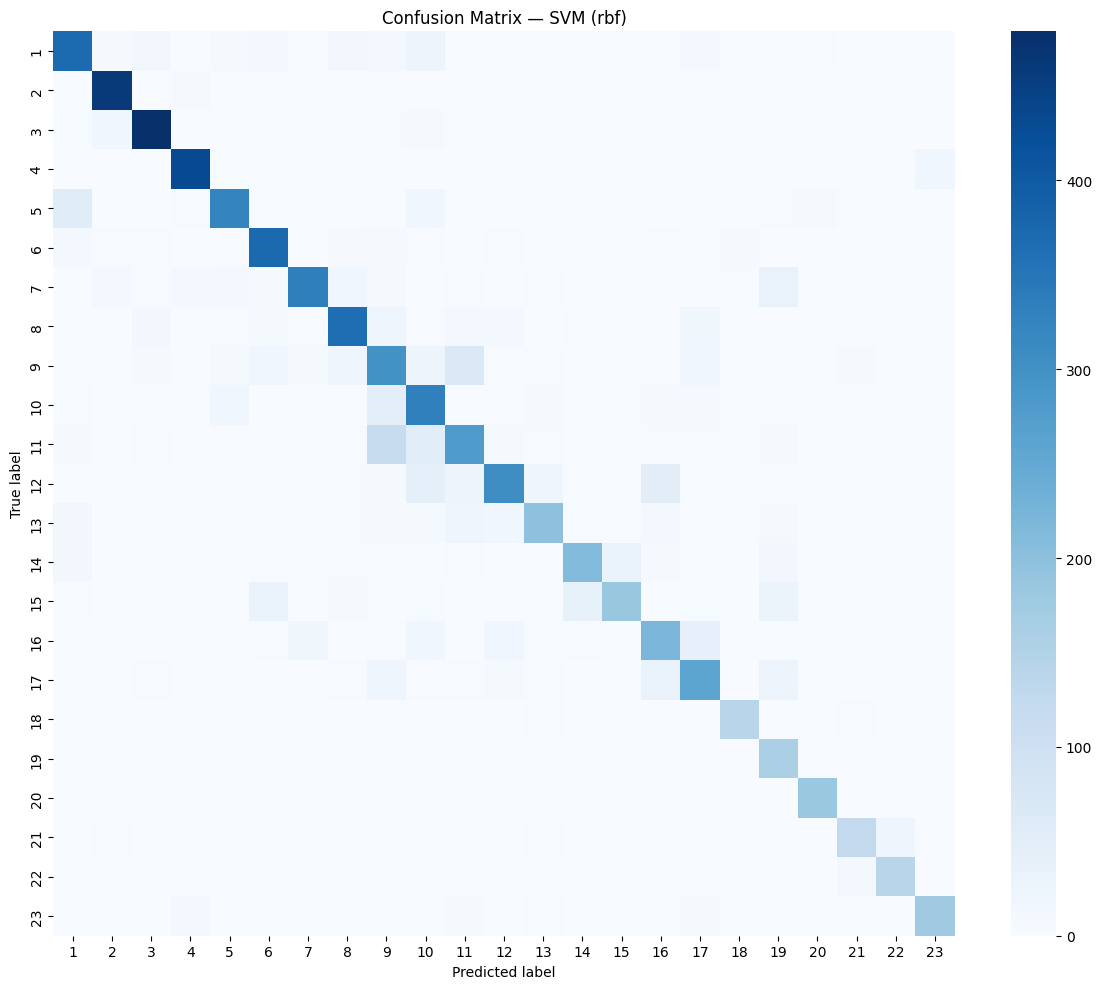

              precision    recall  f1-score   support

           1       0.75      0.77      0.76       480
           2       0.91      0.97      0.94       475
           3       0.90      0.92      0.91       522
           4       0.92      0.93      0.93       461
           5       0.84      0.78      0.81       415
           6       0.79      0.87      0.82       431
           7       0.91      0.74      0.81       451
           8       0.79      0.78      0.79       465
           9       0.53      0.60      0.56       496
          10       0.61      0.78      0.68       426
          11       0.65      0.58      0.61       485
          12       0.81      0.66      0.73       466
          13       0.78      0.65      0.71       307
          14       0.81      0.73      0.77       292
          15       0.85      0.61      0.71       306
          16       0.63      0.67      0.65       332
          17       0.69      0.71      0.70       365
          18       0.90    

In [9]:
y_pred_best = model_predictions[best_macro_name]
cm = confusion_matrix(y_test_enc, y_pred_best)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues", xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel("Predicted label"); plt.ylabel("True label")
plt.title(f"Confusion Matrix — {best_macro_name}")
plt.tight_layout()
plt.show()

print(classification_report(y_test_enc, y_pred_best, target_names=[str(c) for c in encoder.classes_], zero_division=0))

### ROC and Precision-Recall Curves (One-vs-Rest, macro-averaged) — Best Model

For a multi-class problem, a macro-averaged ROC/PR curve is computed by averaging the
per-class one-vs-rest curves — this is the standard approach for visualizing multi-class
ranking performance in one plot.

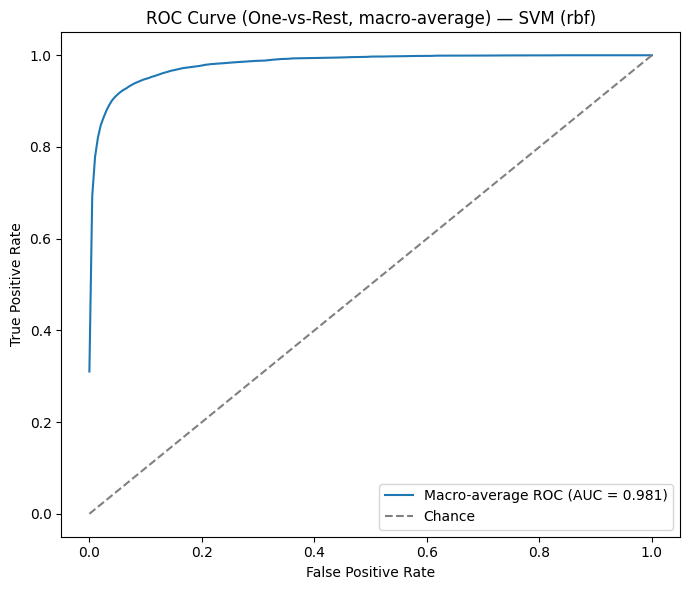

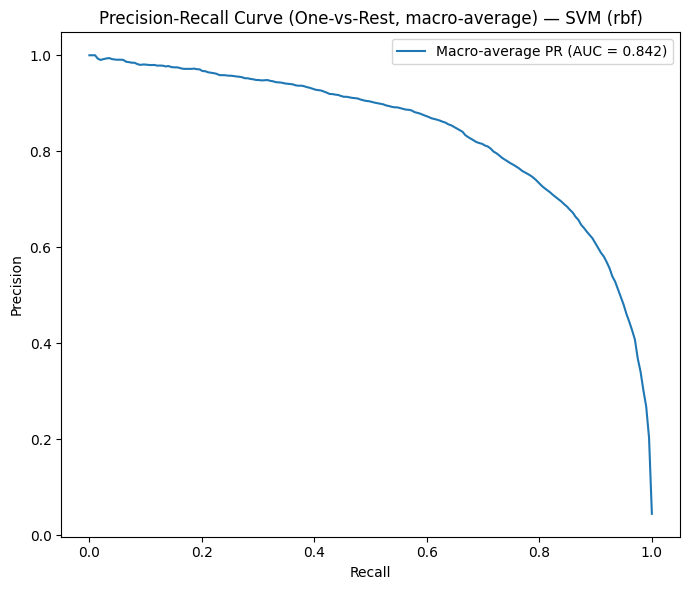

In [10]:
from sklearn.metrics import roc_curve, precision_recall_curve

y_proba_best = model_probabilities[best_macro_name]

if y_proba_best is not None:
    n_classes = y_test_bin.shape[1]

    # --- ROC curves (macro-average via interpolation) ---
    fpr_grid = np.linspace(0, 1, 200)
    mean_tpr = np.zeros_like(fpr_grid)
    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_proba_best[:, i])
        mean_tpr += np.interp(fpr_grid, fpr_i, tpr_i)
    mean_tpr /= n_classes

    plt.figure(figsize=(7, 6))
    plt.plot(fpr_grid, mean_tpr, label=f"Macro-average ROC (AUC = {roc_auc_score(y_test_bin, y_proba_best, average='macro', multi_class='ovr'):.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (One-vs-Rest, macro-average) — {best_macro_name}")
    plt.legend(); plt.tight_layout(); plt.show()

    # --- Precision-Recall curves (macro-average via interpolation) ---
    recall_grid = np.linspace(0, 1, 200)
    mean_prec = np.zeros_like(recall_grid)
    for i in range(n_classes):
        prec_i, rec_i, _ = precision_recall_curve(y_test_bin[:, i], y_proba_best[:, i])
        # precision_recall_curve returns recall in decreasing order; sort for interpolation
        order = np.argsort(rec_i)
        mean_prec += np.interp(recall_grid, rec_i[order], prec_i[order])
    mean_prec /= n_classes

    plt.figure(figsize=(7, 6))
    plt.plot(recall_grid, mean_prec, label=f"Macro-average PR (AUC = {average_precision_score(y_test_bin, y_proba_best, average='macro'):.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve (One-vs-Rest, macro-average) — {best_macro_name}")
    plt.legend(); plt.tight_layout(); plt.show()
else:
    print(f"{best_macro_name} does not expose predict_proba; ROC/PR curves skipped.")

## 8. 1D-CNN Baseline (Raw Windows)

Trained directly on raw EMG+glove window signals (not the extracted/selected features
used by the classical models above).

In [11]:
if tf_available:
    print("\n" + "="*70)
    print("Preparing raw windows for 1D-CNN...")
    print("="*70)

    raw_windows = []
    raw_labels = []
    raw_subjects = []

    for (subject, exercise, repetition, gesture), group in dataset.groupby(
        ["subject", "exercise", "repetition", "restimulus"]
    ):
        if gesture == 0:
            continue
        group = group.reset_index(drop=True)
        if len(group) < WINDOW_SIZE:
            continue
        for start in range(0, len(group)-WINDOW_SIZE+1, STEP_SIZE):
            window = group.iloc[start:start+WINDOW_SIZE]
            raw_win = window[ALL_CHANNELS].values
            raw_windows.append(raw_win)
            raw_labels.append(gesture)
            raw_subjects.append(subject)

    raw_windows = np.array(raw_windows, dtype=np.float32)
    raw_labels = np.array(raw_labels)
    raw_subjects = np.array(raw_subjects)

    # Split by subject
    train_mask = (raw_subjects >= 1) & (raw_subjects <= 20)
    test_mask = (raw_subjects >= 21) & (raw_subjects <= 27)
    X_train_raw = raw_windows[train_mask]
    y_train_raw = raw_labels[train_mask]
    X_test_raw = raw_windows[test_mask]
    y_test_raw = raw_labels[test_mask]

    # Encode labels
    encoder_cnn = LabelEncoder()
    y_train_raw_enc = encoder_cnn.fit_transform(y_train_raw)
    y_test_raw_enc = encoder_cnn.transform(y_test_raw)

    print(f"CNN Train: {X_train_raw.shape[0]}, Test: {X_test_raw.shape[0]}")

    # Normalize per channel (using training stats only)
    mean_train = X_train_raw.mean(axis=(0,1), keepdims=True)
    std_train = X_train_raw.std(axis=(0,1), keepdims=True) + 1e-8
    X_train_raw_norm = (X_train_raw - mean_train) / std_train
    X_test_raw_norm = (X_test_raw - mean_train) / std_train

    # Build CNN
    num_classes = len(encoder_cnn.classes_)
    input_shape = (WINDOW_SIZE, len(ALL_CHANNELS))

    cnn_model = keras_models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(filters=32, kernel_size=5, activation='relu'),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(filters=64, kernel_size=5, activation='relu'),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(filters=128, kernel_size=5, activation='relu'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

    cnn_model.summary()

    print("\nTraining 1D-CNN (20 epochs)...")
    start_time = time.time()
    history = cnn_model.fit(
        X_train_raw_norm, y_train_raw_enc,
        validation_split=0.2,
        epochs=20,
        batch_size=64,
        verbose=1
    )
    train_time_cnn = time.time() - start_time

    # Evaluate
    cnn_loss, cnn_acc = cnn_model.evaluate(X_test_raw_norm, y_test_raw_enc, verbose=0)
    cnn_proba = cnn_model.predict(X_test_raw_norm, verbose=0)   # ADDED: keep raw probabilities for ROC/PR
    cnn_pred = np.argmax(cnn_proba, axis=1)
    cnn_prec, cnn_rec, cnn_f1 = precision_score(y_test_raw_enc, cnn_pred, average='weighted', zero_division=0), \
                                 recall_score(y_test_raw_enc, cnn_pred, average='weighted', zero_division=0), \
                                 f1_score(y_test_raw_enc, cnn_pred, average='weighted', zero_division=0)

    print(f"1D-CNN Test Accuracy: {cnn_acc:.4f}, Precision: {cnn_prec:.4f}, Recall: {cnn_rec:.4f}, F1: {cnn_f1:.4f}, Time: {train_time_cnn:.2f}s")

    # Add CNN results
    results.append({
        "Model": "1D-CNN",
        "Accuracy": cnn_acc,
        "Precision": cnn_prec,
        "Recall": cnn_rec,
        "F1": cnn_f1,
        "Train Time (s)": train_time_cnn
    })


Preparing raw windows for 1D-CNN...
CNN Train: 22724, Test: 8212


I0000 00:00:1787148296.974579      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787148296.977462      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 196, 32)        │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 94, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 47, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 43, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,295 (258.96 KB)

 Trainable params: 66,295 (258.96 KB)

 Non-trainable params: 0 (0.00 B)


Training 1D-CNN (20 epochs)...
Epoch 1/20
 45/285 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1083 - loss: 3.0114

I0000 00:00:1787148304.326075     106 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


285/285 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.5013 - loss: 1.6223 - val_accuracy: 0.6700 - val_loss: 1.0223
Epoch 2/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7652 - loss: 0.7200 - val_accuracy: 0.6847 - val_loss: 1.1058
Epoch 3/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8222 - loss: 0.5389 - val_accuracy: 0.6810 - val_loss: 1.0693
Epoch 4/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8502 - loss: 0.4467 - val_accuracy: 0.7239 - val_loss: 1.0513
Epoch 5/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8718 - loss: 0.3907 - val_accuracy: 0.7289 - val_loss: 1.1203
Epoch 6/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8859 - loss: 0.3392 - val_accuracy: 0.7413 - val_loss: 1.1315
Epoch 7/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8961 - loss: 0.3086 - val_accuracy: 0.7556 - val_loss: 1.1156
Epoch 8/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9071 - loss: 0.2926 - val_accuracy: 0.7437 - va

### 1D-CNN — Macro Metrics & Confusion Matrix

CNN uses a separate label encoding (`encoder_cnn`) since it trains on raw windows
independently from the classical-model pipeline above.

1D-CNN Macro-Precision: 0.6331 | Macro-Recall: 0.6226 | Macro-F1: 0.6198
1D-CNN ROC-AUC (macro, OvR): 0.9448 | PR-AUC (macro, OvR): 0.6565


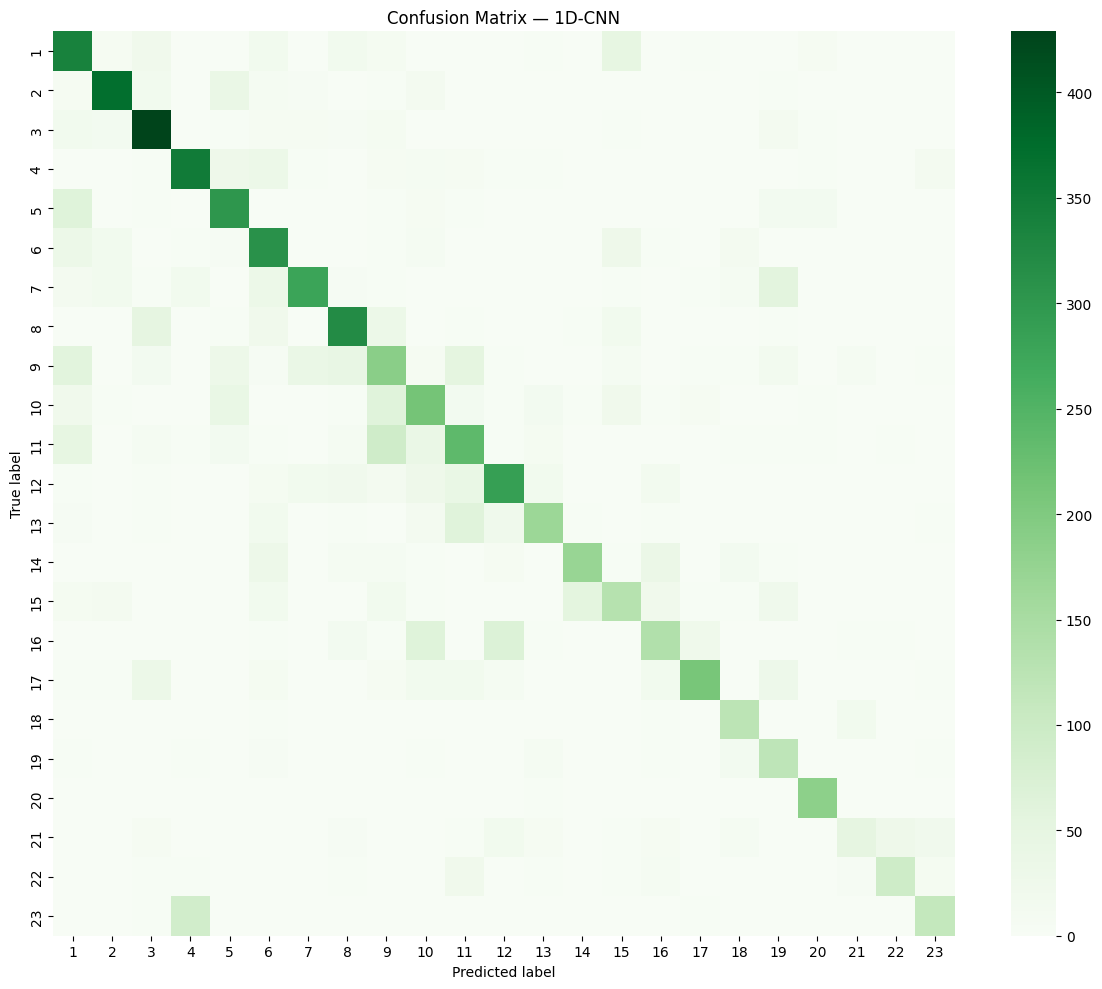

In [12]:
if tf_available:
    cnn_macro_prec = precision_score(y_test_raw_enc, cnn_pred, average='macro', zero_division=0)
    cnn_macro_rec = recall_score(y_test_raw_enc, cnn_pred, average='macro', zero_division=0)
    cnn_macro_f1 = f1_score(y_test_raw_enc, cnn_pred, average='macro', zero_division=0)

    cnn_classes = sorted(np.unique(y_test_raw_enc))
    y_test_raw_bin = label_binarize(y_test_raw_enc, classes=cnn_classes)
    cnn_roc_auc = roc_auc_score(y_test_raw_bin, cnn_proba, average='macro', multi_class='ovr')
    cnn_pr_auc = average_precision_score(y_test_raw_bin, cnn_proba, average='macro')

    print(f"1D-CNN Macro-Precision: {cnn_macro_prec:.4f} | Macro-Recall: {cnn_macro_rec:.4f} | Macro-F1: {cnn_macro_f1:.4f}")
    print(f"1D-CNN ROC-AUC (macro, OvR): {cnn_roc_auc:.4f} | PR-AUC (macro, OvR): {cnn_pr_auc:.4f}")

    cm_cnn = confusion_matrix(y_test_raw_enc, cnn_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_cnn, cmap="Greens", xticklabels=encoder_cnn.classes_, yticklabels=encoder_cnn.classes_)
    plt.xlabel("Predicted label"); plt.ylabel("True label")
    plt.title("Confusion Matrix — 1D-CNN")
    plt.tight_layout()
    plt.show()

## 9. Final Comparison Table

In [13]:
final_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
print("\n" + "="*70)
print("FINAL BASELINE COMPARISON (sorted by Accuracy)")
print("="*70)
print(final_df.to_string(index=False, float_format="%.4f"))

# Save results
final_df.to_csv("Baseline_Results.csv", index=False)
print("\nResults saved to 'Baseline_Results.csv'")

# Highlight the baseline to beat (best classical model)
best_classical_model = final_df[final_df["Model"] != "1D-CNN"].iloc[0]
print("\n" + "="*70)
print(f"BASELINE TO BEAT: {best_classical_model['Model']} (Accuracy = {best_classical_model['Accuracy']:.4f})")
print("="*70)

print("\nAlso saving the macro-metric comparison table (§6.1 full metric set):")
macro_df.to_csv("Baseline_Macro_Results.csv", index=False)
print(macro_df.round(4))
print("\nRemember to click 'Save Version' so Baseline_Results.csv and")
print("Baseline_Macro_Results.csv become this notebook's Output, for the")
print("proposed-model notebook to load for its final comparison table.")


FINAL BASELINE COMPARISON (sorted by Accuracy)
              Model  Accuracy  Precision  Recall     F1  Train Time (s)
          SVM (rbf)    0.7746     0.7836  0.7746 0.7750        100.8818
      Random Forest    0.7482     0.7536  0.7482 0.7462         20.3379
           LightGBM    0.7404     0.7593  0.7404 0.7423         34.3001
            XGBoost    0.7306     0.7473  0.7306 0.7302         61.0600
                MLP    0.6874     0.7082  0.6874 0.6865         44.4194
         k-NN (k=7)    0.6841     0.6930  0.6841 0.6853          0.0038
             1D-CNN    0.6248     0.6319  0.6248 0.6223         36.2972
Logistic Regression    0.6231     0.6663  0.6231 0.6244         18.3038
      Decision Tree    0.4664     0.4687  0.4664 0.4607          9.5813

Results saved to 'Baseline_Results.csv'

BASELINE TO BEAT: SVM (rbf) (Accuracy = 0.7746)

Also saving the macro-metric comparison table (§6.1 full metric set):
                 Model  Macro-Precision  Macro-Recall  Macro-F1  \
1   